In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv("E-commerce Customer Behavior - Sheet1.csv")

In [16]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [17]:
df.shape

(350, 11)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [19]:
df.describe().round(2)

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.00,350.00,350.00,350.00,350.00,350.00
mean,275.50,33.60,845.38,12.60,4.02,26.59
std,101.18,4.87,362.06,4.16,0.58,13.44
min,101.00,26.00,410.80,7.00,3.00,9.00
25%,188.25,30.00,502.00,9.00,3.50,15.00
50%,275.50,32.50,775.20,12.00,4.10,23.00
75%,362.75,37.00,1160.60,15.00,4.50,38.00
max,450.00,43.00,1520.10,21.00,4.90,63.00


In [20]:
missing = df.isnull().sum()

In [21]:
print(missing[missing > 0])

Satisfaction Level    2
dtype: int64


In [22]:
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")


Total missing cells: 2


In [23]:
print("Gender values:         ", df['Gender'].unique())
print("Membership Type values:", df['Membership Type'].unique())
print("City values:           ", df['City'].unique())
print("Satisfaction values:   ", df['Satisfaction Level'].unique())
print("Discount values:       ", df['Discount Applied'].unique())

Gender values:          ['Female' 'Male']
Membership Type values: ['Gold' 'Silver' 'Bronze']
City values:            ['New York' 'Los Angeles' 'Chicago' 'San Francisco' 'Miami' 'Houston']
Satisfaction values:    ['Satisfied' 'Neutral' 'Unsatisfied' nan]
Discount values:        [ True False]


In [24]:
print(df['Satisfaction Level'].value_counts())

Satisfaction Level
Satisfied      125
Unsatisfied    116
Neutral        107
Name: count, dtype: int64


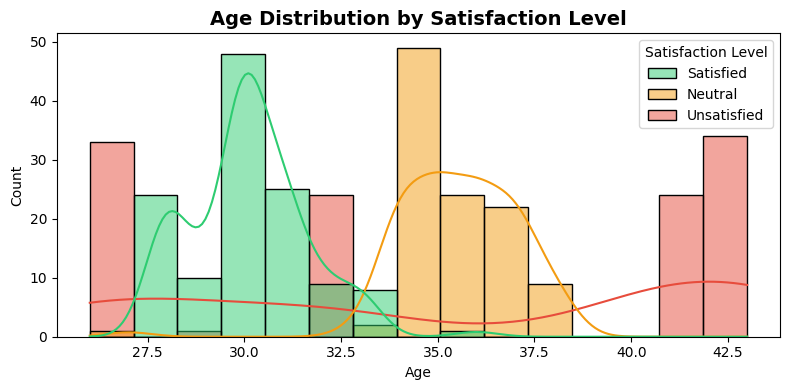

In [25]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x='Age', hue='Satisfaction Level',
             kde=True, bins=15,
             palette=['#2ecc71', '#f39c12', '#e74c3c'])

plt.title('Age Distribution by Satisfaction Level', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_7402/2332450708.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Membership Type', y='Total Spend',


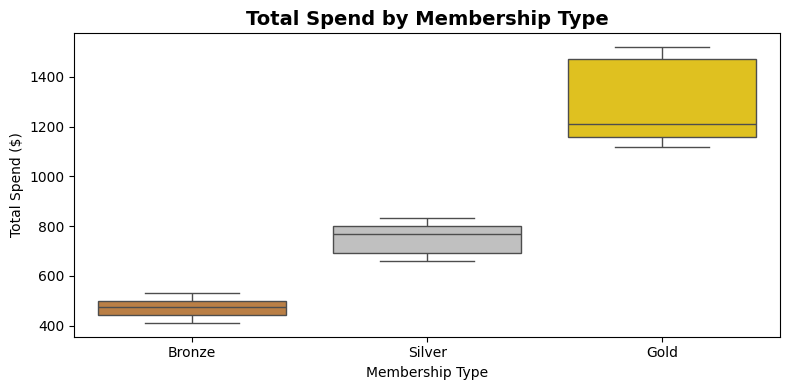

In [26]:
plt.figure(figsize=(8, 4))

sns.boxplot(data=df, x='Membership Type', y='Total Spend',
            order=['Bronze', 'Silver', 'Gold'],
            palette=['#cd7f32', '#C0C0C0', '#FFD700'])

plt.title('Total Spend by Membership Type', fontsize=14, fontweight='bold')
plt.xlabel('Membership Type')
plt.ylabel('Total Spend ($)')
plt.tight_layout()
plt.show()

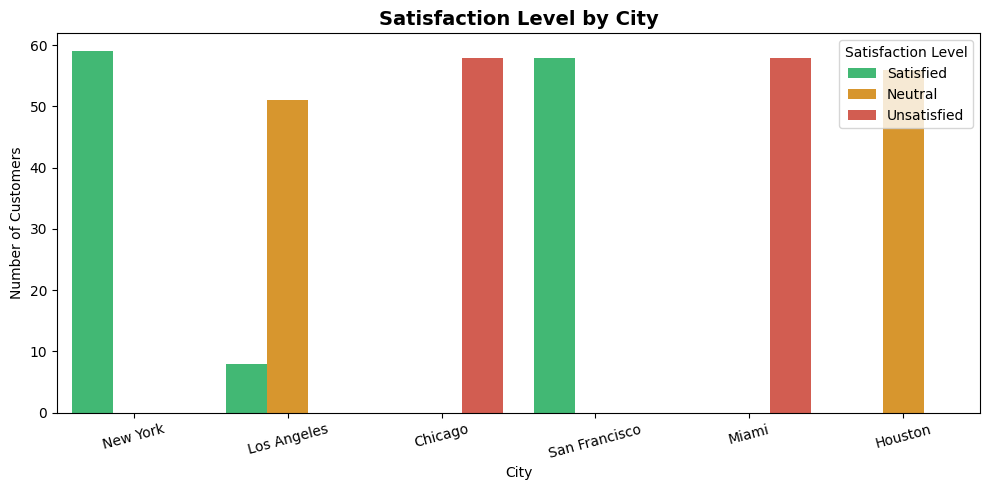

In [27]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x='City', hue='Satisfaction Level',
              palette=['#2ecc71', '#f39c12', '#e74c3c'])

plt.title('Satisfaction Level by City', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)  # Tilt city names so they don't overlap
plt.tight_layout()
plt.show()

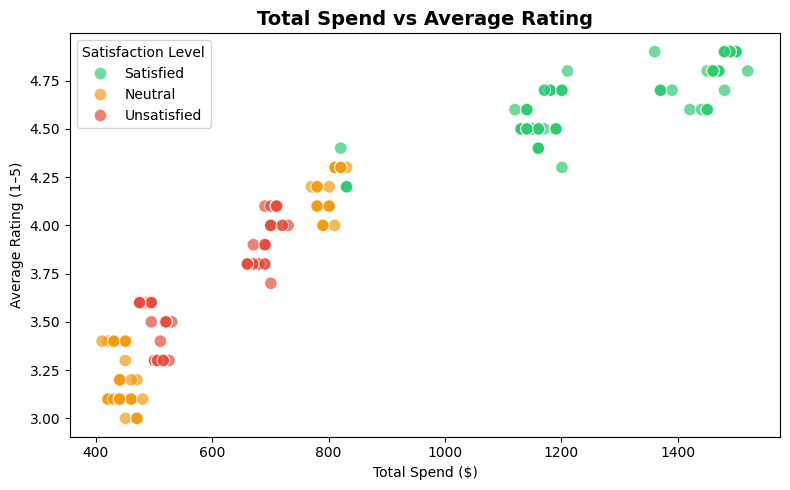

In [28]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='Total Spend', y='Average Rating',
                hue='Satisfaction Level',
                palette=['#2ecc71', '#f39c12', '#e74c3c'],
                alpha=0.7, s=80)  # alpha=transparency, s=dot size

plt.title('Total Spend vs Average Rating', fontsize=14, fontweight='bold')
plt.xlabel('Total Spend ($)')
plt.ylabel('Average Rating (1–5)')
plt.tight_layout()
plt.show()

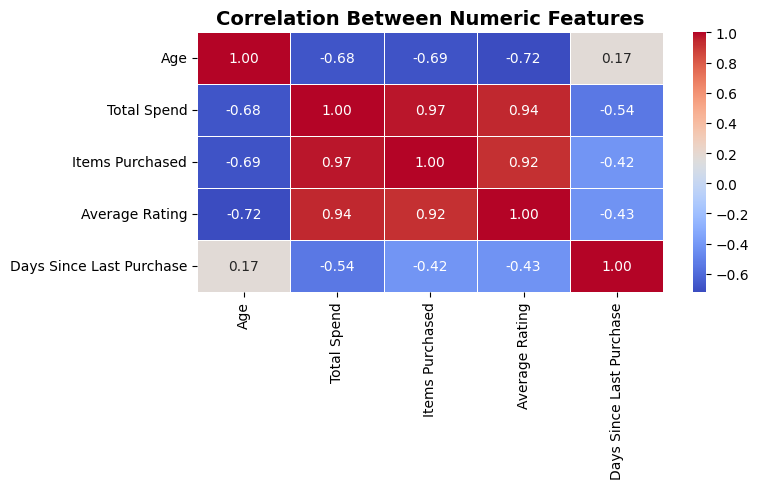

In [29]:
num_cols = ['Age', 'Total Spend', 'Items Purchased',
            'Average Rating', 'Days Since Last Purchase']

plt.figure(figsize=(8, 5))

sns.heatmap(df[num_cols].corr().round(2),
            annot=True,       # Show the numbers inside each box
            cmap='coolwarm',  # Red = positive, Blue = negative
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Between Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
satisfaction_map = {
    'Unsatisfied' : 0,
    'Neutral'     : 1,
    'Satisfied'   : 2
}

df['Satisfaction_Encoded'] = df['Satisfaction Level'].map(satisfaction_map)

# Check it worked
print(df[['Satisfaction Level', 'Satisfaction_Encoded']].head(8))

  Satisfaction Level  Satisfaction_Encoded
0          Satisfied                   2.0
1            Neutral                   1.0
2        Unsatisfied                   0.0
3          Satisfied                   2.0
4        Unsatisfied                   0.0
5            Neutral                   1.0
6          Satisfied                   2.0
7            Neutral                   1.0


In [31]:
membership_map = {
    'Bronze' : 1,
    'Silver' : 2,
    'Gold'   : 3
}

df['Membership_Encoded'] = df['Membership Type'].map(membership_map)

print(df[['Membership Type', 'Membership_Encoded']].head(6))

  Membership Type  Membership_Encoded
0            Gold                   3
1          Silver                   2
2          Bronze                   1
3            Gold                   3
4          Silver                   2
5          Bronze                   1


In [32]:
df = pd.get_dummies(df, columns=['Gender', 'City'], drop_first=True)

# Discount Applied is True/False — convert to 1/0
df['Discount Applied'] = df['Discount Applied'].astype(int)

print("✅ Encoding done!")
print(f"New shape: {df.shape}")
print("\nNew columns added:")
print(df.columns.tolist())

✅ Encoding done!
New shape: (350, 17)

New columns added:
['Customer ID', 'Age', 'Membership Type', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase', 'Satisfaction Level', 'Satisfaction_Encoded', 'Membership_Encoded', 'Gender_Male', 'City_Houston', 'City_Los Angeles', 'City_Miami', 'City_New York', 'City_San Francisco']


In [33]:
feature_cols = [
    'Age',
    'Total Spend',
    'Items Purchased',
    'Average Rating',
    'Discount Applied',
    'Days Since Last Purchase',
    'Membership_Encoded',
    'Gender_Male',
    'City_Houston',
    'City_Los Angeles',
    'City_Miami',
    'City_New York',
    'City_San Francisco',
]

X = df[feature_cols]   # X = Features (inputs to the model)
y = df['Satisfaction_Encoded']  # y = Target (what we want to predict)

print(f"✅ Features (X) shape: {X.shape}")
print(f"✅ Target  (y) shape: {y.shape}")
print(f"\nFeature columns:\n{X.columns.tolist()}")

✅ Features (X) shape: (350, 13)
✅ Target  (y) shape: (350,)

Feature columns:
['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase', 'Membership_Encoded', 'Gender_Male', 'City_Houston', 'City_Los Angeles', 'City_Miami', 'City_New York', 'City_San Francisco']


In [34]:
print("NaN in y before fix:", y.isna().sum())

mask = y.notna()
X = X[mask]
y = y[mask]

print("NaN in y after fix :", y.isna().sum())
print(f"\nNew X shape: {X.shape}")
print(f"New y shape: {y.shape}")

NaN in y before fix: 2
NaN in y after fix : 0

New X shape: (348, 13)
New y shape: (348,)


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ← very important!
)

print(f"✅ Split done!")
print(f"\nTraining set : {X_train.shape[0]} customers")
print(f"Testing set  : {X_test.shape[0]} customers")
print(f"\nSatisfaction balance in TRAIN:")
print(y_train.value_counts().sort_index())
print(f"\nSatisfaction balance in TEST:")
print(y_test.value_counts().sort_index())

✅ Split done!

Training set : 278 customers
Testing set  : 70 customers

Satisfaction balance in TRAIN:
Satisfaction_Encoded
0.0     93
1.0     85
2.0    100
Name: count, dtype: int64

Satisfaction balance in TEST:
Satisfaction_Encoded
0.0    23
1.0    22
2.0    25
Name: count, dtype: int64


In [38]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    n_estimators  = 100,
    random_state  = 42,
    class_weight  = 'balanced'
)

rf_model.fit(X_train, y_train)

print("✅ Model trained on 100 decision trees!")
print(f"Features used: {X_train.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")

✅ Model trained on 100 decision trees!
Features used: 13
Training samples: 278


In [39]:
y_pred = rf_model.predict(X_test)

print("First 10 predictions vs actual:")
print(f"\nPredicted : {list(y_pred[:10].astype(int))}")
print(f"Actual    : {list(y_test[:10].astype(int))}")

correct = (y_pred == y_test).sum()
print(f"\n✅ Got {correct} out of {len(y_test)} correct!")

First 10 predictions vs actual:

Predicted : [np.int64(0), np.int64(2), np.int64(2), np.int64(1), np.int64(0), np.int64(1), np.int64(2), np.int64(0), np.int64(1), np.int64(2)]
Actual    : [0, 2, 2, 1, 0, 1, 2, 0, 1, 2]

✅ Got 70 out of 70 correct!


📊 Classification Report:
              precision    recall  f1-score   support

 Unsatisfied       1.00      1.00      1.00        23
     Neutral       1.00      1.00      1.00        22
   Satisfied       1.00      1.00      1.00        25

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



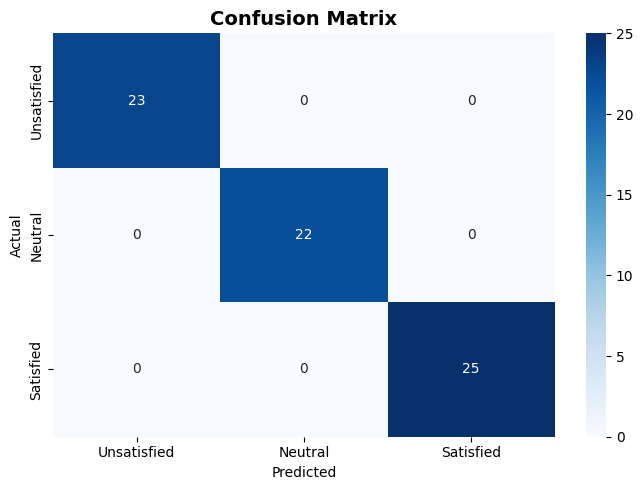

In [40]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


print("📊 Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['Unsatisfied', 'Neutral', 'Satisfied']
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Unsatisfied', 'Neutral', 'Satisfied'],
            yticklabels=['Unsatisfied', 'Neutral', 'Satisfied'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth'    : [None, 5, 10, 20],
    'min_samples_split' : [2, 5, 10],
}

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'recall_macro',
    n_jobs     = -1,
    verbose    = 1
)

print("🔍 Searching best parameters... (takes ~30 seconds)")
grid_search.fit(X_train, y_train)

print(f"\n✅ Best parameters found:")
print(grid_search.best_params_)
print(f"\nBest recall score: {grid_search.best_score_:.4f}")

🔍 Searching best parameters... (takes ~30 seconds)
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Best parameters found:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Best recall score: 1.0000


In [42]:
best_model = grid_search.best_estimator_

# Test it on our test set
y_pred_best = best_model.predict(X_test)

# Compare with original model
from sklearn.metrics import accuracy_score, recall_score

original_acc = accuracy_score(y_test, y_pred)
best_acc     = accuracy_score(y_test, y_pred_best)

original_recall = recall_score(y_test, y_pred, average='macro')
best_recall     = recall_score(y_test, y_pred_best, average='macro')

print("📊 Original Model vs Tuned Model:")
print(f"\n{'Metric':<15} {'Original':>10} {'Tuned':>10}")
print("-" * 35)
print(f"{'Accuracy':<15} {original_acc:>10.4f} {best_acc:>10.4f}")
print(f"{'Recall':<15} {original_recall:>10.4f} {best_recall:>10.4f}")

📊 Original Model vs Tuned Model:

Metric            Original      Tuned
-----------------------------------
Accuracy            1.0000     1.0000
Recall              1.0000     1.0000


In [43]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for metric in ['accuracy', 'recall_macro', 'f1_macro']:

    scores = cross_val_score(
        best_model, X, y,
        cv      = skf,
        scoring = metric
    )

    print(f"\n{metric.upper()}")
    print(f"  Per fold : {[round(s, 4) for s in scores]}")
    print(f"  Mean     : {scores.mean():.4f}")
    print(f"  Std Dev  : {scores.std():.4f}  ← lower = more consistent")


ACCURACY
  Per fold : [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.9855), np.float64(1.0)]
  Mean     : 0.9971
  Std Dev  : 0.0058  ← lower = more consistent

RECALL_MACRO
  Per fold : [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.9867), np.float64(1.0)]
  Mean     : 0.9973
  Std Dev  : 0.0053  ← lower = more consistent

F1_MACRO
  Per fold : [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.9854), np.float64(1.0)]
  Mean     : 0.9971
  Std Dev  : 0.0058  ← lower = more consistent


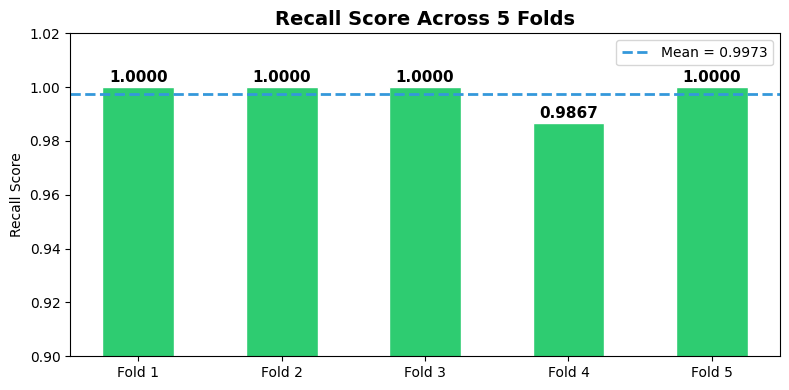

In [46]:
cv_recall = cross_val_score(best_model, X, y, cv=skf, scoring='recall_macro')

colors = ['#2ecc71' if score > 0.95 else '#e74c3c' for score in cv_recall]

plt.figure(figsize=(8, 4))
bars = plt.bar(
    [f'Fold {i+1}' for i in range(5)],
    cv_recall,
    color=colors,
    width=0.5,
    edgecolor='white'
)

# Mean line
plt.axhline(cv_recall.mean(), color='#3498db',
            linestyle='--', linewidth=2,
            label=f'Mean = {cv_recall.mean():.4f}')

# Value labels on top of bars
for bar, val in zip(bars, cv_recall):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{val:.4f}', ha='center',
             fontweight='bold', fontsize=11)

plt.ylim(0.90, 1.02)
plt.title('Recall Score Across 5 Folds', fontsize=14, fontweight='bold')
plt.ylabel('Recall Score')
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_prob = best_model.predict_proba(X_test)

print(f"y_prob shape: {y_prob.shape}")
print(f"Sample probabilities (first 3 rows):")
print(y_prob[:3].round(3))

auc_score = roc_auc_score(
    y_test_bin,
    y_prob,
    average='macro',
    multi_class='ovr'
)

print(f"\n✅ AUC Score: {auc_score:.4f}")
if auc_score >= 0.99:
    print("🏆 Outstanding — near perfect class separation!")
elif auc_score >= 0.95:
    print("✅ Excellent model performance")
elif auc_score >= 0.90:
    print("👍 Good model performance")
else:
    print("⚠️ Model needs improvement")

y_prob shape: (70, 3)
Sample probabilities (first 3 rows):
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]

✅ AUC Score: 1.0000
🏆 Outstanding — near perfect class separation!


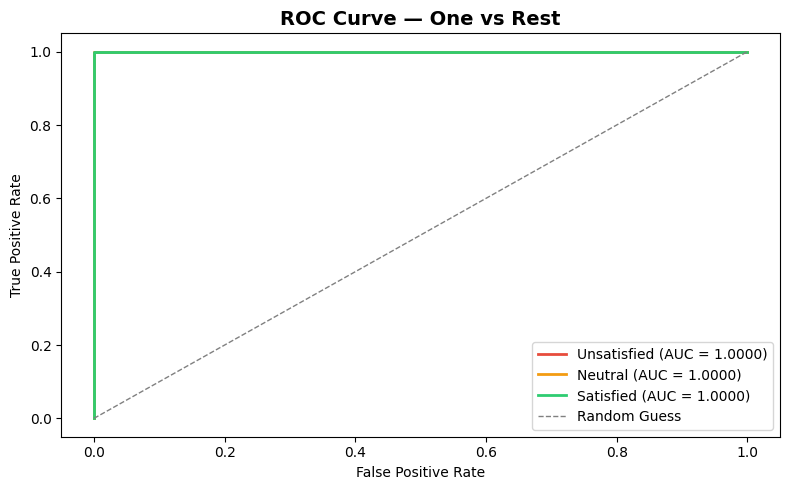

In [50]:
from sklearn.metrics import roc_curve, auc

class_names = ['Unsatisfied', 'Neutral', 'Satisfied']
colors_roc  = ['#e74c3c', '#f39c12', '#2ecc71']

plt.figure(figsize=(8, 5))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc_val = auc(fpr, tpr)

    plt.plot(fpr, tpr,
             color=colors_roc[i],
             linewidth=2,
             label=f'{class_names[i]} (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1],
         color='gray', linestyle='--',
         linewidth=1, label='Random Guess')

plt.title('ROC Curve — One vs Rest', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [51]:
importances = best_model.feature_importances_
feature_names = X.columns

# Put into a DataFrame and sort from highest to lowest
feat_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Importance' : importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("📊 Feature Importances:")
print(feat_df.to_string(index=False))

📊 Feature Importances:
                 Feature   Importance
Days Since Last Purchase 1.951011e-01
             Total Spend 1.741285e-01
        Discount Applied 1.415369e-01
      Membership_Encoded 1.227681e-01
         Items Purchased 1.102837e-01
          Average Rating 1.087943e-01
                     Age 7.207840e-02
            City_Houston 2.463546e-02
        City_Los Angeles 2.239911e-02
              City_Miami 1.816164e-02
             Gender_Male 5.597588e-03
           City_New York 4.515119e-03
      City_San Francisco 1.466424e-16


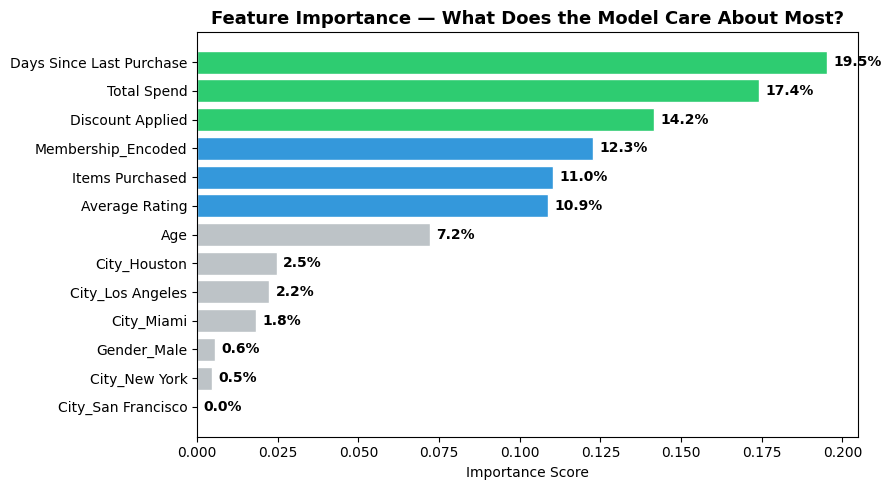

In [52]:
plt.figure(figsize=(9, 5))

colors_feat = ['#2ecc71' if i < 3 else '#3498db' if i < 6 else '#bdc3c7'
               for i in range(len(feat_df))]

bars = plt.barh(
    feat_df['Feature'],
    feat_df['Importance'],
    color=colors_feat,
    edgecolor='white'
)

# Add percentage labels on each bar
for bar, val in zip(bars, feat_df['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', fontsize=10, fontweight='bold')

plt.xlabel('Importance Score')
plt.title('Feature Importance — What Does the Model Care About Most?',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()   # Most important at top
plt.tight_layout()
plt.show()

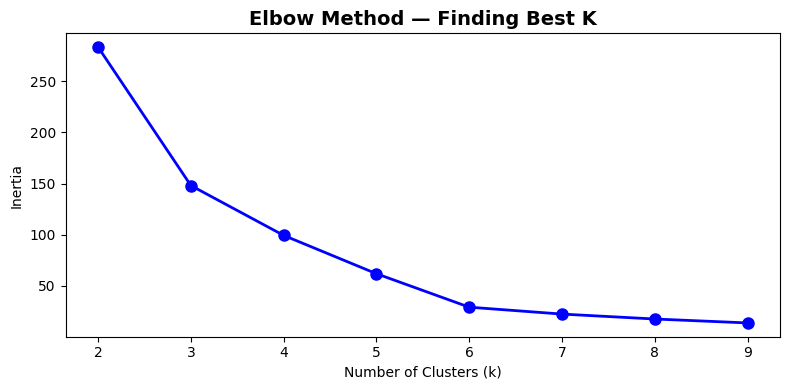

Look for the 'elbow' — where the curve bends and flattens!


In [53]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
cluster_features = ['Total Spend', 'Days Since Last Purchase']
X_cluster = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Best K', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

print("Look for the 'elbow' — where the curve bends and flattens!")


In [54]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print("Customers per cluster:")
print(df['Cluster'].value_counts().sort_index())
print("\nCluster Profiles:")
print(df.groupby('Cluster')[['Total Spend',
                              'Days Since Last Purchase',
                              'Items Purchased',
                              'Average Rating']].mean().round(2))

Customers per cluster:
Cluster
0    115
1     58
2    118
3     59
Name: count, dtype: int64

Cluster Profiles:
         Total Spend  Days Since Last Purchase  Items Purchased  \
Cluster                                                           
0             630.98                     18.77             9.69   
1            1459.77                     11.17            20.00   
2             592.52                     42.79            10.47   
3            1165.04                     24.59            15.27   

         Average Rating  
Cluster                  
0                  3.69  
1                  4.81  
2                  3.69  
3                  4.54  


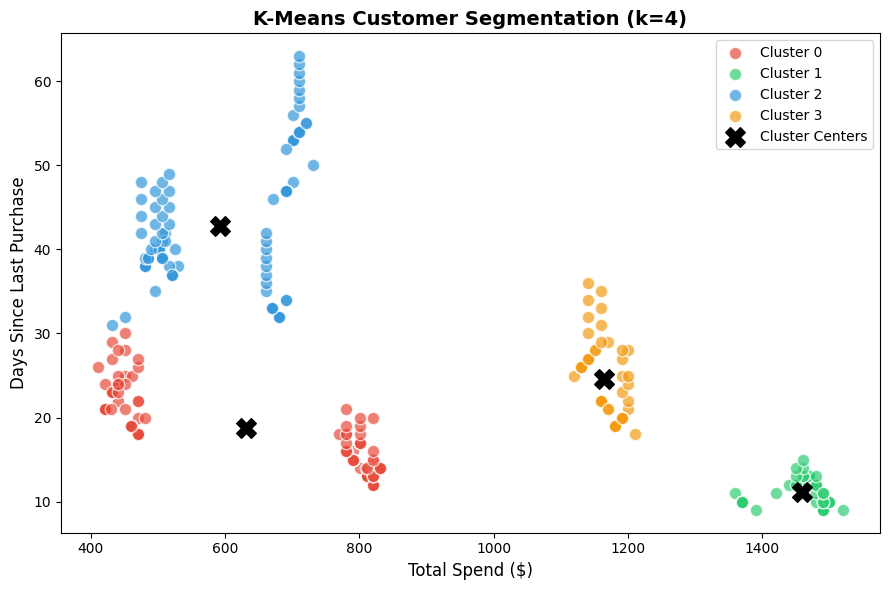

In [55]:
cluster_colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
cluster_labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

plt.figure(figsize=(9, 6))

for i in range(4):
    mask = df['Cluster'] == i
    plt.scatter(
        df[mask]['Total Spend'],
        df[mask]['Days Since Last Purchase'],
        c=cluster_colors[i],
        label=cluster_labels[i],
        alpha=0.7, s=80, edgecolors='white'
    )
    centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    c='black', marker='X', s=200,
    zorder=5, label='Cluster Centers'
)

plt.xlabel('Total Spend ($)', fontsize=12)
plt.ylabel('Days Since Last Purchase', fontsize=12)
plt.title('K-Means Customer Segmentation (k=4)', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
segment_names = {
    0: '🔴 At Risk',
    1: '🟢 Champions',
    2: '🔵 Loyal',
    3: '🟡 Potential'
}
print("Satisfaction Level per Cluster:")
print(pd.crosstab(df['Cluster'],
                  df['Satisfaction Level'],
                  normalize='index').round(2) * 100)

Satisfaction Level per Cluster:
Satisfaction Level  Neutral  Satisfied  Unsatisfied
Cluster                                            
0                      93.0        7.0          0.0
1                       0.0      100.0          0.0
2                       2.0        0.0         98.0
3                       0.0      100.0          0.0


In [57]:
segment_names = {
    1: '🏆 Champions',
    3: '💛 Loyal Customers',
    0: '🌱 Potential',
    2: '🚨 At Risk'
}

df['Segment'] = df['Cluster'].map(segment_names)

print("Customer count per segment:")
print(df['Segment'].value_counts())

Customer count per segment:
Segment
🚨 At Risk            118
🌱 Potential          115
💛 Loyal Customers     59
🏆 Champions           58
Name: count, dtype: int64


/tmp/ipykernel_7402/2564232965.py:21: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7402/2564232965.py:21: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7402/2564232965.py:21: UserWarning: Glyph 128155 (\N{YELLOW HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7402/2564232965.py:21: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPytho

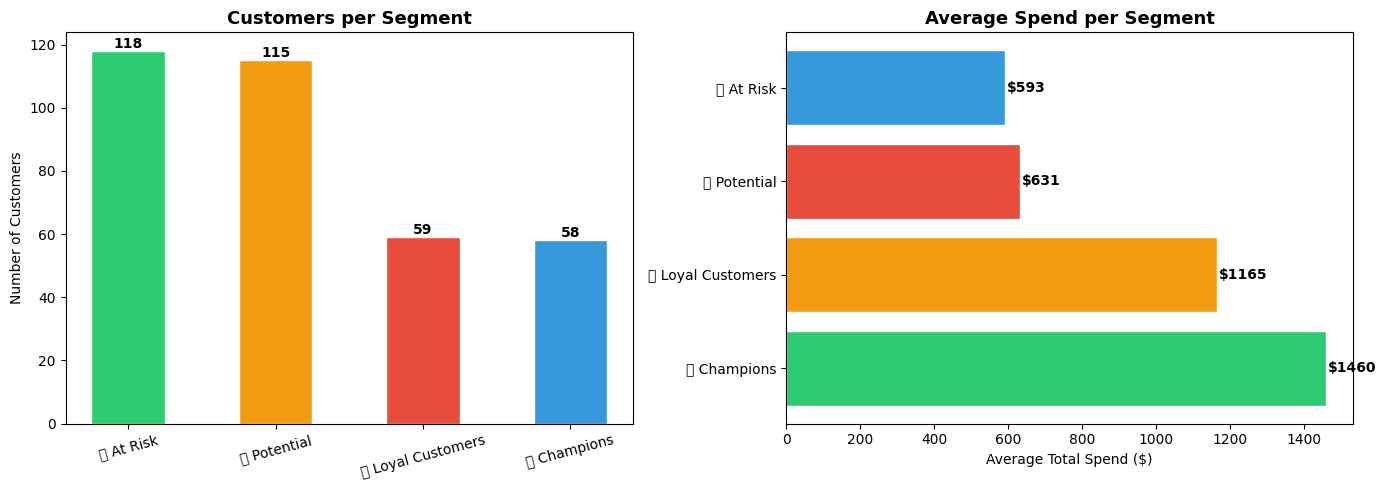

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
segment_counts = df['Segment'].value_counts()
colors_seg = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']

axes[0].bar(segment_counts.index, segment_counts.values,
            color=colors_seg, edgecolor='white', width=0.5)
axes[0].set_title('Customers per Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=15)
for i, (idx, val) in enumerate(segment_counts.items()):
    axes[0].text(i, val + 1, str(val), ha='center', fontweight='bold')
    segment_spend = df.groupby('Segment')['Total Spend'].mean().sort_values(ascending=False)

axes[1].barh(segment_spend.index, segment_spend.values,
             color=colors_seg, edgecolor='white')
axes[1].set_title('Average Spend per Segment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Total Spend ($)')
for i, val in enumerate(segment_spend.values):
    axes[1].text(val + 5, i, f'${val:.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [62]:
segment_summary = df.groupby('Segment').agg(
    Count        = ('Segment', 'count'),
    Avg_Spend    = ('Total Spend', 'mean'),
    Avg_Days     = ('Days Since Last Purchase', 'mean'),
    Avg_Rating   = ('Average Rating', 'mean')
).round(2)

print(segment_summary.to_string())

                 Count  Avg_Spend  Avg_Days  Avg_Rating
Segment                                                
At Risk            118     592.52     42.79        3.69
Champions           58    1459.77     11.17        4.81
Loyal Customers     59    1165.04     24.59        4.54
Potential          115     630.98     18.77        3.69
